# Evaluating the ML temperature forecasting models

Comparison of **OU / Ridge / Random Forest / XGBoost** on the metric that matters for pricing:
the **APE on cumulative indices** (HDD and CAT), not daily RMSE alone. Protocol:

- **Forecast origin: 2020-01-01** (`APP_START`), right after the end of the training window
  (1950→2019), a period never seen by the models.
- **recursive walk-forward forecasting**: each predicted day feeds the next day's lags, model
  kept frozen (no retraining). This is the only honest mode for a pricing horizon.
- **Different horizons**: from the origin (30/90/365 days) and with *lead time* (ISL = one season
  ahead, IISL = two, Mid-90 = a 90-day window starting 4.5 months out). The latter mimics the
  real-world purchase of a seasonal derivative months before the covered period.
- **OLS excluded**: it diverges recursively after trying it, because of the non inversibility of the matrix $XX^t$. One-step benchmark only.

All the machinery lives in `src/` (`temperature_mc.horizon_metrics`, `evaluation.py`). This notebook only calls and visualizes it.

In [1]:
import sys, os; sys.path.append("../../src")
os.environ["PYTHONWARNINGS"] = "ignore"   # also silences joblib/loky worker processes
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from temperature_mc import horizon_metrics, load_city, load_model, ALL_CITIES
from ml_simulation import recursive_forecast
from evaluation import compute_ape_winters
from config import APP_START

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})
MODEL_COLORS = {"ou": "#1f4e79", "ridge": "#2ca02c", "rf": "#d4882b", "xgb": "#9467bd"}
HORIZON_ORDER = ["30-day", "90-day", "365-day", "ISL", "IISL", "Mid-90"]
print("Cities:", ALL_CITIES)

Cities: ['chicago', 'new_york', 'boston', 'minneapolis', 'dallas', 'los_angeles', 'seattle']


## 1. Horizon table (all 7 cities)

A single call computes the HDD/CAT APE for every (city × model × horizon). The aggregated
tables measure **generalisability**: a good pricing model must work everywhere, not on a
hand-picked city.

In [2]:
M = horizon_metrics(models=("ou", "ridge", "rf", "xgb"), verbose=False)
M.to_csv("../../outputs/horizon_metrics_all.csv", index=False)
print(f"{M.city.nunique()} cities × {M.model.nunique()} models × {M.label.nunique()} horizons "
      f"= {len(M)} rows")

  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


7 cities × 4 models × 6 horizons = 168 rows


In [3]:
def mean_table(metric):
    return (M.pivot_table(index="label", columns="model", values=metric, aggfunc="mean")
              .reindex(HORIZON_ORDER)[["ou", "ridge", "rf", "xgb"]].round(4))

print("HDD APE, mean over the 7 cities")
display(mean_table("ape_hdd"))
print("CAT APE, mean over the 7 cities")
display(mean_table("ape_cat"))

HDD APE, mean over the 7 cities


model,ou,ridge,rf,xgb
label,,,,
30-day,0.1804,0.1668,0.1376,0.1412
90-day,0.1488,0.1239,0.0876,0.1032
365-day,0.0378,0.0803,0.0778,0.1072
ISL,0.3443,0.4339,0.3730,0.5530
IISL,0.7775,0.8158,0.7976,0.8330
Mid-90,0.6648,0.7271,0.7782,0.6102


CAT APE, mean over the 7 cities


model,ou,ridge,rf,xgb
label,,,,
30-day,0.7438,0.7744,0.6281,0.3659
90-day,0.5088,0.4931,0.2581,0.2549
365-day,0.0431,0.0315,0.0333,0.0592
ISL,0.0443,0.0345,0.0492,0.0723
IISL,0.0284,0.0292,0.0307,0.0424
Mid-90,0.0286,0.0334,0.0281,0.0333


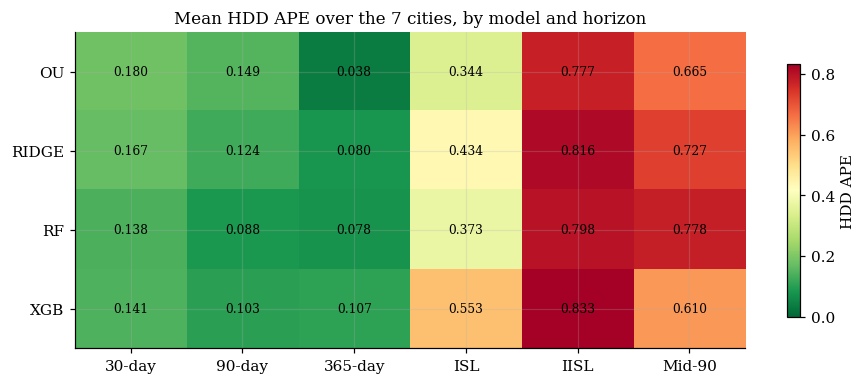

In [4]:
# Mean HDD APE heatmap, instant read: green = good, per horizon
t = mean_table("ape_hdd")
fig, ax = plt.subplots(figsize=(8.5, 3.6))
im = ax.imshow(t.T.values, cmap="RdYlGn_r", aspect="auto",
               vmin=0, vmax=np.nanmax(t.values))
ax.set_xticks(range(len(t.index)), t.index)
ax.set_yticks(range(len(t.columns)), [c.upper() for c in t.columns])
for i in range(t.shape[1]):
    for j in range(t.shape[0]):
        ax.text(j, i, f"{t.T.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
ax.set_title("Mean HDD APE over the 7 cities, by model and horizon")
fig.colorbar(im, label="HDD APE", shrink=0.8)
fig.tight_layout()

In [5]:
# How often is each model the BEST (over 7 cities × 6 horizons)?
def rank_wins(metric):
    best = (M.pivot_table(index=["city", "label"], columns="model", values=metric)
              [["ou", "ridge", "rf", "xgb"]].idxmin(axis=1))
    return best.value_counts().rename(f"#1 {metric}")

pd.concat([rank_wins("ape_hdd"), rank_wins("ape_cat")], axis=1).fillna(0).astype(int)

,#1 ape_hdd,#1 ape_cat
ou,16,9
xgb,11,11
rf,8,10
ridge,6,12


## 2. City focus: Chicago

Horizon-level detail for a representative city (continental climate, strong seasonality,
the typical HDD use case). Change `FOCUS_CITY` for another city.

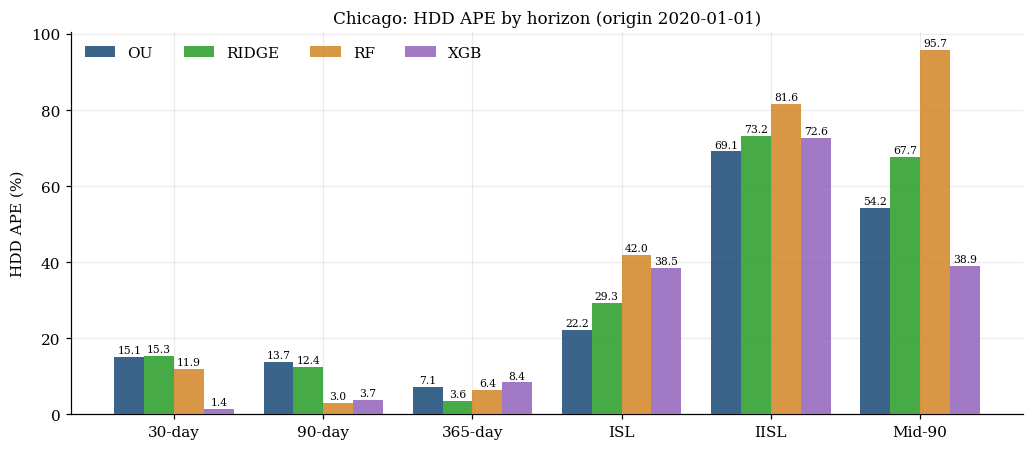

In [6]:
FOCUS_CITY = "chicago"
piv = (M[M.city == FOCUS_CITY]
       .pivot_table(index="label", columns="model", values="ape_hdd")
       .reindex(HORIZON_ORDER)[["ou", "ridge", "rf", "xgb"]])

fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = np.arange(len(piv.index)); width = 0.2
for i, m in enumerate(piv.columns):
    vals = piv[m].values * 100
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=m.upper(),
                  color=MODEL_COLORS[m], alpha=0.88, zorder=3)
    for b, v in zip(bars, vals):
        if np.isfinite(v):
            ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}",
                    ha="center", va="bottom", fontsize=7)
ax.set_xticks(x, piv.index); ax.set_ylabel("HDD APE (%)")
ax.set_title(f"{FOCUS_CITY.capitalize()}: HDD APE by horizon (origin {APP_START})")
ax.legend(frameon=False, ncols=4)
fig.tight_layout()

## 3. Winter-by-winter HDD APE (Chicago)

Horizons aggregate. Here we look at **each test winter** separately (Nov→Mar, recursive
forecast restarted from the origin). This is the contract's granularity: a desk lives winter
by winter, not on average.

  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


,ridge,rf,xgb
winter,,,
2020/2021,0.0591,0.0068,0.0701
2021/2022,0.0165,0.0481,0.0896
2022/2023,0.0915,0.0049,0.0017
2023/2024,0.2201,0.1466,0.0545
2024/2025,0.0631,0.0249,0.0321
2025/2026,0.0473,0.1026,0.0788


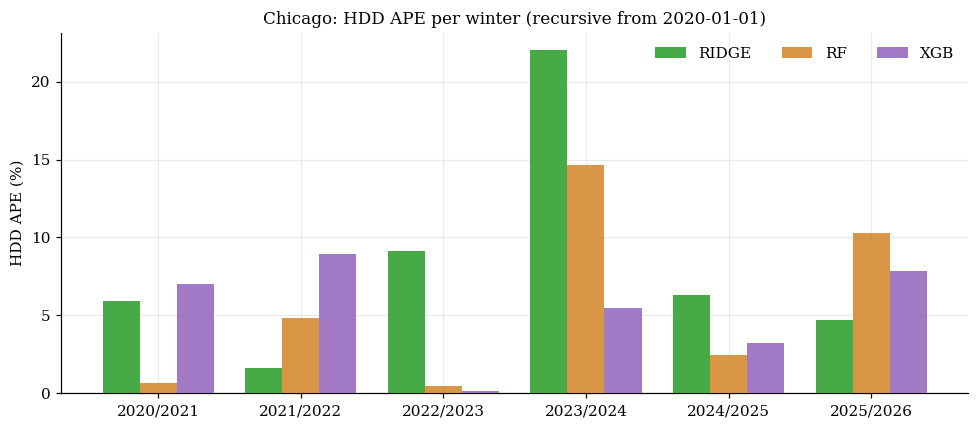

In [7]:
df, feat = load_city(FOCUS_CITY)
end = str(feat.index.max().date())

winters = {}
for name in ("ridge", "rf", "xgb"):
    preds, div = recursive_forecast(load_model(FOCUS_CITY, name), feat, APP_START, end)
    if div:
        continue
    w = compute_ape_winters(preds)
    winters[name] = w.set_index("winter")["ape_hdd"]

W = pd.DataFrame(winters)
W = W[~W.index.isin(["MEAN"])].dropna(how="all")
display(W.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(W.index)); width = 0.26
for i, m in enumerate(W.columns):
    ax.bar(x + (i - 1) * width, W[m].values * 100, width, label=m.upper(),
           color=MODEL_COLORS[m], alpha=0.88, zorder=3)
ax.set_xticks(x, W.index, rotation=0); ax.set_ylabel("HDD APE (%)")
ax.set_title(f"{FOCUS_CITY.capitalize()}: HDD APE per winter (recursive from {APP_START})")
ax.legend(frameon=False, ncols=3)
fig.tight_layout()

- **Short/medium horizons (30/90 days)**: ML keeps a **modest edge** over the OU on cumulative HDD,
 about **1.2× at 30 days and 1.7× at 90 days** (best ML vs OU, mean over the 7 cities). Recent lags carry information the OU climatology smooths away, but the gain is moderate **once the recursive forecast is made strictly causal** (no leakage of the realized anomaly through the annual-delta features `dX_kyr`).
- **Long / lead-time horizons (365-day, ISL, IISL, Mid-90)**: the edge vanishes and the OU becomes competitive or better, because the recursive error accumulated during the lead pulls every model back to its implied climatology. This is the horizon that matters to the market, and the central caveat of the forecasting contest (workstream 3a): **a forecasting edge at 30 to 90 days does not survive to the seasonal pricing horizon.**
- The winter-by-winter performance shows the **inter-annual variability** of the ranking: no model wins every winter, which motivates the full Monte Carlo distribution over a point forecast.

# Monte Carlo: from point forecasts to HDD distributions

The horizon metrics above evaluate the models as **deterministic** forecasters. But a
derivative payoff depends on the *whole distribution* of cumulative HDD, not one path.
We turn each deterministic model into a Monte-Carlo generator by **resampling its
out-of-sample recursive forecast errors** $e_t = T_t^{\text{real}} - \hat T_t$ (test 2020+)
on top of the forecast:
$$\hat T_t^{(j)} = \hat T_t + e_t^{(j)}, \qquad e_t^{(j)} \overset{\text{i.i.d.}}{\sim} \hat F_e^{(\text{month})}.$$
The errors are **empirical**, so they carry the skew/kurtosis a Gaussian would miss. We
stratify by **month** because the dispersion is seasonal. These pools are exactly what the
pricing notebook (`6_Pricing`) resamples.

  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


,n,mean,std,skew,exces_kurt
ridge,2188.0,0.936,4.727,-0.118,0.272
rf,2188.0,0.046,4.730,-0.168,0.305
xgb,2188.0,0.172,4.876,-0.390,0.692


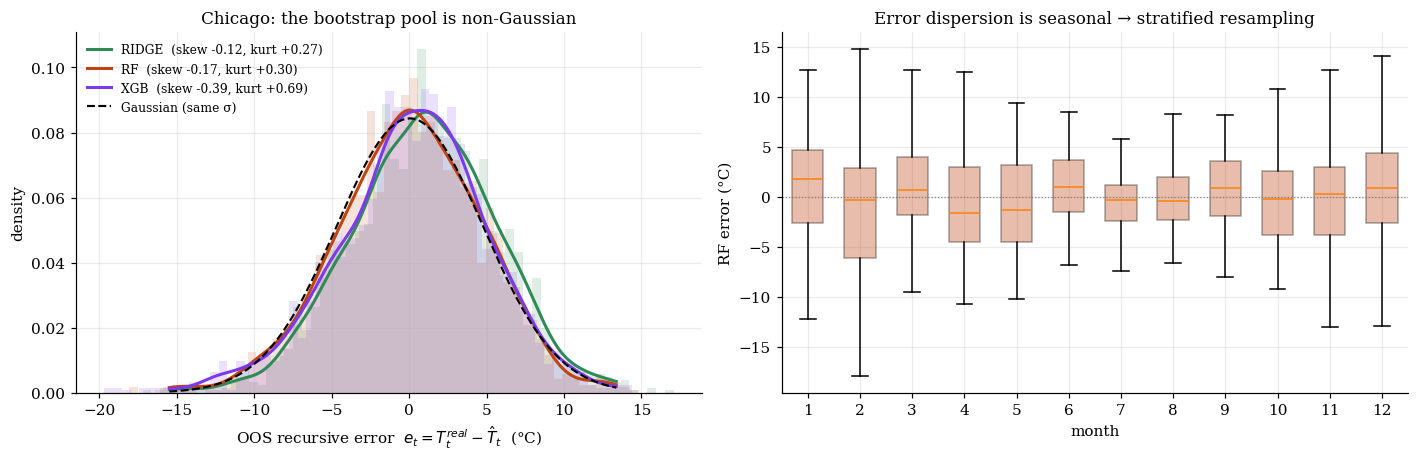

In [8]:
from temperature_mc import recursive_errors, load_city, load_model, make_pool
from ml_simulation import simulate_ml
from ou_simulation import load_ou_params, simulate_ou, x0_from_dataset
from pricing import hdd_cumulative, get_season_windows
from scipy.stats import gaussian_kde, skew, kurtosis, norm

CITY = "chicago"
S, T1, T2 = "2022-10-01", "2022-11-01", "2023-03-31"          # focus winter
COL = {"ridge": "#2e8b57", "rf": "#c1440e", "xgb": "#7c3aed",
       "ou": "#1f4e79", "burn": "#555555"}
df, feat = load_city(CITY)

pools = {}
for m in ("ridge", "rf", "xgb"):
    err, diverged = recursive_errors(load_model(CITY, m), feat, CITY, m)
    if not diverged:
        pools[m] = err.dropna()

moments = pd.DataFrame({m: {"n": len(e), "mean": e.mean(), "std": e.std(),
                            "skew": skew(e), "exces_kurt": kurtosis(e)}
                        for m, e in pools.items()}).T
display(moments.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
lo = min(e.quantile(.005) for e in pools.values()); hi = max(e.quantile(.995) for e in pools.values())
grid = np.linspace(lo, hi, 400)
for m, e in pools.items():
    axes[0].hist(e, bins=60, density=True, color=COL[m], alpha=0.15)
    axes[0].plot(grid, gaussian_kde(e)(grid), color=COL[m], lw=2,
                 label=f"{m.upper()}  (skew {skew(e):+.2f}, kurt {kurtosis(e):+.2f})")
ref = pools["rf"]
axes[0].plot(grid, norm.pdf(grid, ref.mean(), ref.std()), "k--", lw=1.4, label="Gaussian (same σ)")
axes[0].set_xlabel(r"OOS recursive error  $e_t = T_t^{real} - \hat T_t$  (°C)")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8, frameon=False)
axes[0].set_title(f"{CITY.title()}: the bootstrap pool is non-Gaussian")

e = pools["rf"]
data = [e[e.index.month == mth].values for mth in range(1, 13)]
bp = axes[1].boxplot(data, positions=list(range(1, 13)), widths=0.6, showfliers=False, patch_artist=True)
for patch in bp["boxes"]: patch.set(facecolor=COL["rf"], alpha=0.35)
axes[1].axhline(0, color="grey", lw=0.8, ls=":")
axes[1].set_xlabel("month"); axes[1].set_ylabel("RF error (°C)")
axes[1].set_title("Error dispersion is seasonal → stratified resampling")
fig.tight_layout()

## The simulation: forecast + resampled errors

Each Monte-Carlo path = the deterministic recursive forecast **plus** an independently
resampled error path. Below, a focus winter for Random Forest: the cone is the spread the
bootstrap injects around the forecast.

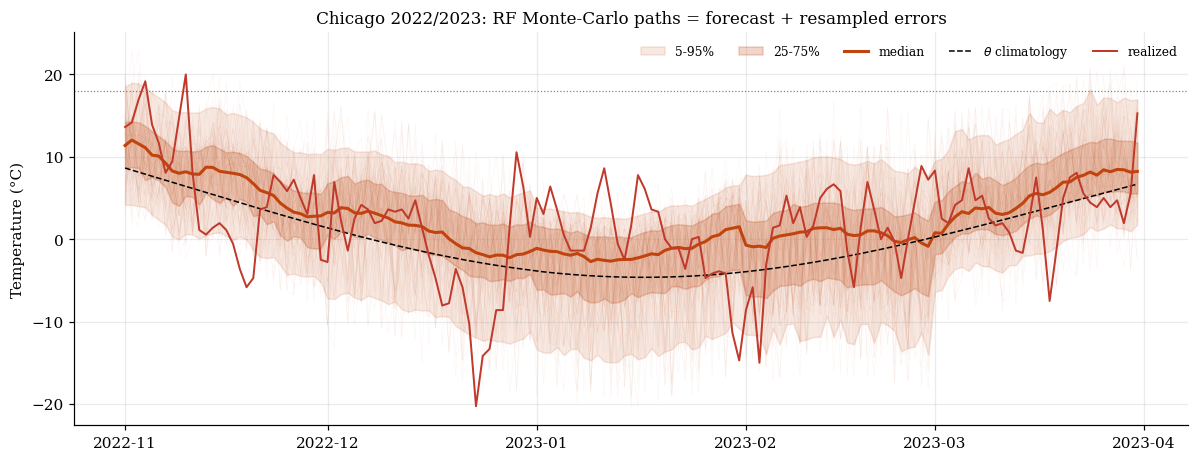

In [9]:
m = "rf"
err, _ = recursive_errors(load_model(CITY, m), feat, CITY, m)
pool = make_pool(err, exclude=(T1, T2))
traj = simulate_ml(load_model(CITY, m), feat, T1, T2, pool, n_sims=2000, pricing_start=S, seed=1)
q = traj.quantile([.05, .25, .5, .75, .95], axis=1).T
real = df.loc[T1:T2, "T"]; theta = df.loc[T1:T2, "theta"]

fig, ax = plt.subplots(figsize=(11, 4.3))
for j in range(60):
    ax.plot(traj.index, traj.iloc[:, j], color=COL[m], lw=0.4, alpha=0.05)
ax.fill_between(q.index, q[0.05], q[0.95], color=COL[m], alpha=0.12, label="5-95%")
ax.fill_between(q.index, q[0.25], q[0.75], color=COL[m], alpha=0.22, label="25-75%")
ax.plot(q.index, q[0.5], color=COL[m], lw=2, label="median")
ax.plot(theta.index, theta.values, "k--", lw=1, label=r"$\theta$ climatology")
ax.plot(real.index, real.values, color="#c0392b", lw=1.3, label="realized")
ax.axhline(18, color="grey", lw=0.8, ls=":")
ax.set_ylabel("Temperature (°C)")
ax.set_title(f"{CITY.title()} {T1[:4]}/{T2[:4]}: RF Monte-Carlo paths = forecast + resampled errors")
ax.legend(ncol=5, fontsize=8, frameon=False); fig.tight_layout()

## HDD distributions across models

Integrating each path into a cumulative HDD gives one distribution per model. The
ridgeline below stacks them: the dispersion **σ_H collapses** from the model-free burn
(true inter-annual spread) down to the conditional models, the ML i.i.d. resampling being
the narrowest.

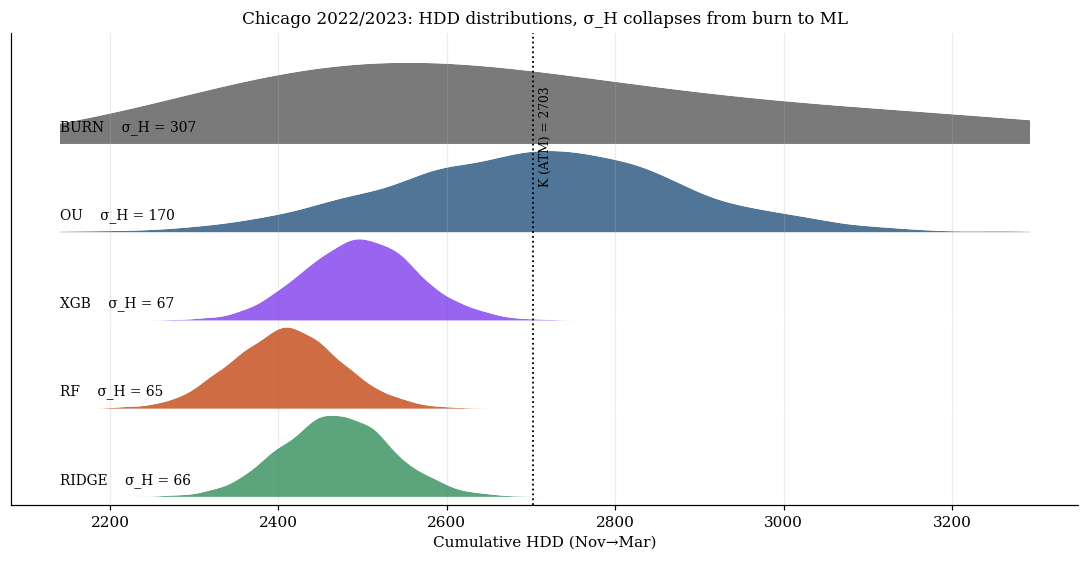

In [10]:
N = 4000
H = {}
for m in ("ridge", "rf", "xgb"):
    err, _ = recursive_errors(load_model(CITY, m), feat, CITY, m)
    pool = make_pool(err, exclude=(T1, T2))
    tj = simulate_ml(load_model(CITY, m), feat, T1, T2, pool, n_sims=N, pricing_start=S, seed=1)
    H[m] = hdd_cumulative(tj).to_numpy()
tj = simulate_ou(load_ou_params(CITY), S, T2, n_sims=N, X0=x0_from_dataset(CITY, S),
                 seed=1).reindex(df.loc[T1:T2].index)
H["ou"] = hdd_cumulative(tj).to_numpy()
wins = get_season_windows(2013, 2022)["winter"]
H["burn"] = np.array([float(np.maximum(18 - df.loc[ws:we, "T"], 0).sum())
                      for ws, we in wins.values() if df.loc[ws:we, "T"].notna().sum() >= 120])

order = ["burn", "ou", "xgb", "rf", "ridge"]                  # wide -> narrow
lo = min(h.min() for h in H.values()); hi = max(h.max() for h in H.values())
grid = np.linspace(lo, hi, 400)
fig, ax = plt.subplots(figsize=(10, 5.2))
for i, m in enumerate(order):
    d = gaussian_kde(H[m])(grid); d = d / d.max() * 0.92
    y0 = len(order) - 1 - i
    ax.fill_between(grid, y0, y0 + d, color=COL[m], alpha=0.78, lw=0, zorder=i)
    ax.plot(grid, y0 + d, color="white", lw=0.7, zorder=i)
    ax.text(lo, y0 + 0.10, f"{m.upper()}    σ_H = {H[m].std(ddof=1):.0f}", fontsize=9, va="bottom")
K = round(H["burn"].mean())
ax.axvline(K, color="k", ls=":", lw=1.2)
ax.text(K + 6, len(order) - 0.35, f"K (ATM) = {K}", rotation=90, va="top", fontsize=8)
ax.set_yticks([]); ax.set_xlabel("Cumulative HDD (Nov→Mar)")
ax.set_ylim(-0.1, len(order) + 0.25)
ax.set_title(f"{CITY.title()} {T1[:4]}/{T2[:4]}: HDD distributions, σ_H collapses from burn to ML")
fig.tight_layout()

> These HDD distributions are the input to **`6_Pricing`**. A call pays
> $\alpha\max(H-K,0)$, so its price is driven by the **dispersion σ_H** seen here, not by
> the mean. The pricing notebook turns this ladder of σ_H into a ladder of prices.

## HDD sums and the call payoffs they induce

The same Monte-Carlo draws, two lenses (Barnor et al., Fig. 13 style): the
cumulative-HDD distribution **with the strike** (left), and the call payoff
$\alpha\max(H-K,0)$ it induces (right). The payoff panel makes the pricing
consequence explicit: a model whose HDD mass sits **below $K$** collapses onto a
spike at zero (deep out-of-the-money), so its call is worth almost nothing, while
a wider model keeps real optionality.

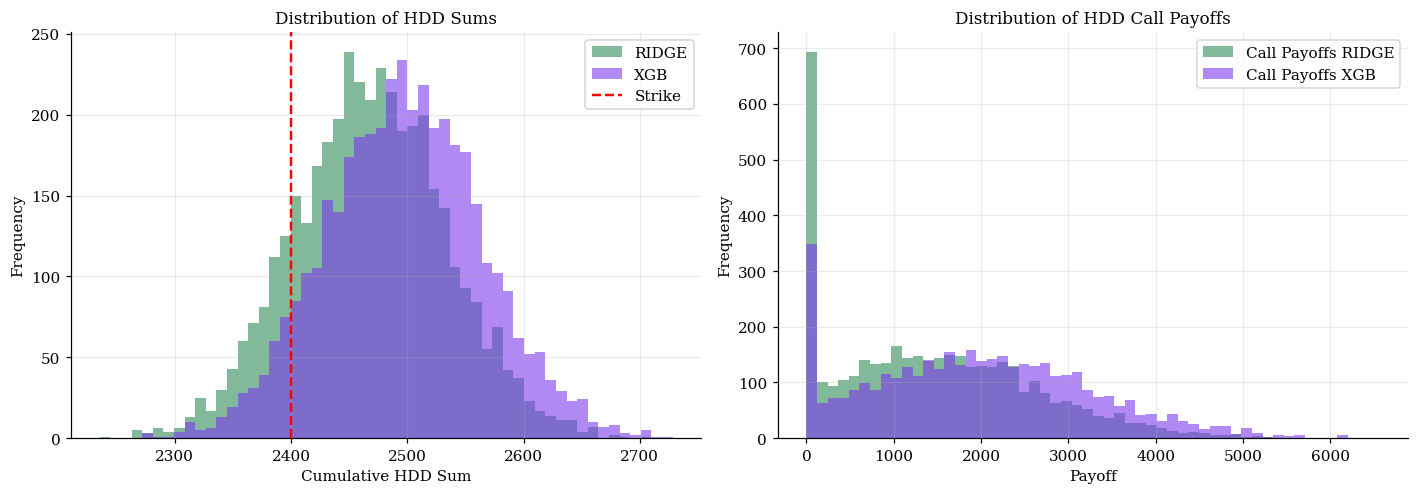

In [11]:
TICK = 20
A, B = "ridge", "xgb"  
K= 2_400                       
payoffs = {m: TICK * np.maximum(H[m] - K, 0) for m in (A, B)}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
bins = np.linspace(min(H[A].min(), H[B].min()), max(H[A].max(), H[B].max()), 55)
for m in (A, B):
    ax[0].hist(H[m], bins=bins, color=COL[m], alpha=0.6, label=m.upper())
ax[0].axvline(K, color="red", ls="--", lw=1.6, label="Strike")
ax[0].set(xlabel="Cumulative HDD Sum", ylabel="Frequency", title="Distribution of HDD Sums")
ax[0].legend()

pbins = np.linspace(0, max(payoffs[A].max(), payoffs[B].max()), 55)
for m in (A, B):
    ax[1].hist(payoffs[m], bins=pbins, color=COL[m], alpha=0.6, label=f"Call Payoffs {m.upper()}")
ax[1].set(xlabel="Payoff", ylabel="Frequency", title="Distribution of HDD Call Payoffs")
ax[1].legend()
fig.tight_layout()

In [12]:
import sys
from pathlib import Path
# repo root = first parent that contains src/, robust to the notebook depth
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
from config import TRAIN_END, APP_START
from temperature_mc import load_city, load_model

CITY = "chicago"
df, feat = load_city(CITY)

def rmse_X(model, sub):                       # one-step error on the target X_{t+1} (°C)
    X, y = sub.drop(columns="target"), sub["target"].to_numpy()
    return float(np.sqrt(np.mean((model.predict(X) - y) ** 2)))

tr, te = feat.loc[:TRAIN_END], feat.loc[APP_START:]
print(f"{CITY}: train {len(tr)} rows | OOS {len(te)} rows\n")
for m in ("ridge", "rf", "xgb"):
    mdl = load_model(CITY, m)
    a, b = rmse_X(mdl, tr), rmse_X(mdl, te)
    print(f"{m:5s}: train RMSE {a:.3f}°C | OOS RMSE {b:.3f}°C | gap ×{b/a:.2f}")

  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183
chicago: train 25532 rows | OOS 2188 rows

ridge: train RMSE 3.392°C | OOS RMSE 3.220°C | gap ×0.95


rf   : train RMSE 3.007°C | OOS RMSE 3.299°C | gap ×1.10
xgb  : train RMSE 3.344°C | OOS RMSE 3.258°C | gap ×0.97


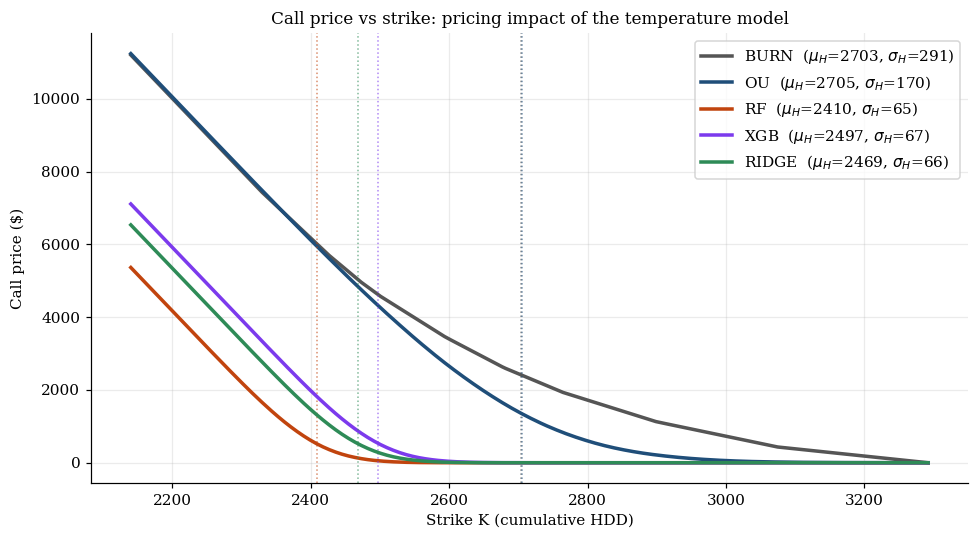

In [13]:
TICK, R = 20, 0.01
TTM  = (pd.Timestamp(T2) - pd.Timestamp(S)).days / 365      # discount s -> t2
disc = np.exp(-R * TTM)

models = ["burn", "ou", "rf", "xgb", "ridge"]           # contrast the dispersions (wide -> narrow)
Kgrid  = np.linspace(min(H[m].min() for m in models),
                     max(H[m].max() for m in models), 250)

def price_curve(Hm):                    # price(K) = alpha * e^{-rT} * E[max(H-K,0)]
    return TICK * disc * np.maximum(Hm[:, None] - Kgrid[None, :], 0).mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
for m in models:
    ax.plot(Kgrid, price_curve(H[m]), color=COL[m], lw=2.3,
            label=f"{m.upper()}  ($\\mu_H$={H[m].mean():.0f}, $\\sigma_H$={H[m].std():.0f})")
    ax.axvline(H[m].mean(), color=COL[m], ls=":", lw=1, alpha=0.6)
ax.set_xlabel("Strike K (cumulative HDD)")
ax.set_ylabel("Call price ($)")
ax.set_title("Call price vs strike: pricing impact of the temperature model")
ax.legend(); fig.tight_layout()